# 線形代数

この章では、線形代数の基本的な事項をまとめる。


## 行列・ベクトルの演算/基本的性質

行列やベクトルの演算は、機械学習は言わずもがな、計算機を用いて行なう演算の基本である。
スパコンの性能ランキングを測る一つのベンチマークは行列演算で、TOP500と呼ばれるランキングが非常に有名である。

日本が有する「富岳」は、2020年6月に1位となり、2021年11月までその座を維持し、
2025年7月に発表されたTOP500のランキングにおいても世界第7位を記録している。

ベクトルの一般的な定義は、「和とスカラー倍に関して閉じている集合」であるが、
機械学習や計算機科学の分野では、実数または複素数成分を持つ量として直感的に定義されることが多い。
$\mathbf{v} \in \mathbb{R}^n \quad$ or $\quad \mathbf{v} \in \mathbb{C}^n$

`numpy`では列ベクトルとして表す。

In [11]:
import numpy as np
v = np.array([1.0, 3.0, 5.0])
print("v", v, "shape", v.shape)

v [1. 3. 5.] shape (3,)


同様に行列も、二次元配列として表現される。適当な2行3列の行列を定義してみよう。

In [12]:
A = np.array([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
print("A", A, "shape", A.shape)

A [[1. 2. 3.]
 [4. 5. 6.]] shape (2, 3)


ベクトルは行列の特殊な場合として定義できるため、以下では特に断りが無い限り行列として扱う。

行列同士の積は、行列の列数と行数が一致する場合に定義される。
具体的には、$A \in \mathbb{R}^{m \times n}, B \in \mathbb{R}^{n \times p}$ のとき、$C = AB \in \mathbb{R}^{m \times p}$ である。
`numpy`では、`@`演算子または`np.matmul`関数を用いて行列積を計算することができる。

```python
C = A @ B
# または
C = np.matmul(A, B)
```

In [13]:
C = A.T @ A # A^T times A
print("C", C, "shape", C.shape)

C [[17. 22. 27.]
 [22. 29. 36.]
 [27. 36. 45.]] shape (3, 3)


In [14]:
C = np.matmul(A.T, A) # A^T times A
print("C", C, "shape", C.shape)

C [[17. 22. 27.]
 [22. 29. 36.]
 [27. 36. 45.]] shape (3, 3)


## 行列式とトレース

行列の行列式やトレースは、行列の特性を表す重要な値である。
行列 $A$ の行列式は、その行列が正方行列である場合に定義され、行列のスケーリングや線形変換の特性を示す。


$$
\begin{align*}
A = \begin{pmatrix}
a_{11} & a_{12} & \cdots & a_{1n} \\
a_{21} & a_{22} & \cdots & a_{2n} \\ 
\vdots & \vdots & \ddots & \vdots \\
a_{m1} & a_{m2} & \cdots & a_{mn}
\end{pmatrix}
\end{align*}
$$

このとき、行列式は以下のように定義される。

$$
\det(A) = |A| = \sum_{\sigma \in S_n} \text{sgn}(\sigma) a_{1\sigma(1)} a_{2\sigma(2)} \cdots a_{n\sigma(n)}
$$

ここで、$\sigma$は$n$次対称群 $S_n$ (1~nまでの整数に対する全ての置換が為す群) の要素であり、$\text{sgn}(\sigma)$ は置換の符号(偶置換か奇置換か)を示す関数である。
なお、$\sigma_{i,j}$は$i,j$の入れ替えを表す。
元の順列が $(1, 2, 3)$だったとき、あり得る置換は以下のようになる。

| 置換 (右から作用させる) | 符号 | 結果 | 
|-------|------|------|
| Identity | 偶置換 | (1, 2, 3)|
|$\sigma_{1,2}$ | 奇置換 | (2, 1, 3)|
|$\sigma_{1,3}$ | 奇置換 | (3, 2, 1)|
|$\sigma_{2,3}$ | 奇置換 | (1, 3, 2)|
|$\sigma_{1,2} \sigma_{2,3}$ | 偶置換 | (3, 1, 2)|
|$\sigma_{1,3} \sigma_{2,3}$ | 偶置換 | (2, 3, 1)|


`````{admonition} 問題
:class: important

$3\times 3$行列式に対する行列式の公式(Sarrusの式)は以下のように表される。

$$
\det(A) = a_{11}a_{22}a_{33} + a_{12}a_{23}a_{31} + a_{13}a_{21}a_{32}
- a_{11}a_{23}a_{32} - a_{12}a_{21}a_{33} - a_{13}a_{22}a_{31}
$$

上の行列式の定義から、サラスの公式を導出せよ。

`````



`````{admonition} 行列式の性質
:class: tip

- 行列式の積: $ \det(AB) = \det(A) \det(B) $
- 行列式の転置: $ \det(A^T) = \det(A) $
- $A$が逆行列を持つとき、$\det(A^{-1}) = 1/\det(A)$
- 行ベクトル(あるいは列ベクトル)のスカラー倍を別の行(列)に加えても $\det(A)$は不変。
- ある行ベクトル(列ベクトル)をスカラー$a$倍すると、$\det(A') = a \det(A)$となる。したがって、$\det(aA) = a^n \det(A)$である。

`````

行列のトレース(trace)は、対角要素の和で定義される:

$$
\text{tr}(A) = \sum^n_{i=1} a_{ii}
$$


`````{admonition} トレースの性質
:class: tip

- 正方行列 $A,B \in \mathbb{R}^{n \times n}$ に対して、$\text{tr}(A+B) = \text{tr}(A)+\text{tr}(B)$
- スカラー$\alpha \in \mathbb{R}$に対して$\text{tr}(\alpha A) = \alpha \text{tr}(A)$
- 行列$A \in \mathbb{R}^{n \times k}, B \in \mathbb{R}^{k \times n}$に対して、$\text{tr}(AB) = \text{tr}(BA)$が成り立つ.

`````

## 逆行列

逆行列は、行列 $A$ に対して $A^{-1}$ と表され、以下の条件を満たす行列である。

$$
A A^{-1} = A^{-1} A = I
$$

ここで、$I$ は単位行列であり、対角成分が全て1で他の成分が0の正方行列である。
逆行列は、行列の線形変換を元に戻す操作を表す。
逆行列が存在する行列を可逆行列または正則行列と呼ぶ。

$n$次正方行列が正則であることと同値な条件は幾つかあるが、代表的なものとして以下が挙げられる:

- 行列式が0でない (Aの固有値が全て0でない)
- 列ベクトルが線形独立である
- 行列のランクが$n$である


:::{margin}
数値計算を専門にする人は、余程のことが無い限り行列の逆行列を求めることは避ける。世の中には逆行列を計算すると破門になる研究室もあるらしい。
:::
たとえばPythonでは`numpy.linalg`モジュールを用いると、行列の逆行列を計算することができる。
...と書いたが、実際の数値計算では、行列の逆行列を求めることは数値的に不安定な場合があり、一般には避けるべきである。
例えば、$Ax = b$ を解く($x$を求める)のに、$x = A^{-1}b$ として逆行列を求める方法は、一般に望ましくない。
Web上に転がっているデータ分析のコードを見ていると、逆行列を求めているものが多いが、これは数値的に不安定な場合があるため、注意が必要である。
では、逆行列を求めずに様々な演算を行うにはどうすればよいのか。そこで必要になるのが、種々の行列の分解になる。
例えばコレスキー分解やLU分解、など対象となる行列の特性に応じて様々な分解が存在する。
これらの分解を用いることで、逆行列を明示的に求めることなく、行列の演算を行うことができる。



### $\clubsuit$ 行列の条件数

行列の条件数(condition number)は、行列の数値的な安定性を評価するためにも用いられる。
条件数の大きな行列は、数値計算において誤差が増幅されやすく、逆行列の計算などが不安定になる可能性があり、悪条件(ill-conditioned)であるとも言われる。

行列 $A$ の条件数は、以下のように定義される。

$$
\kappa(A) = \|A\| \|A^{-1}\|
$$

:::{margin}
行列のノルムという際、誘導されたノルム(作用素ノルム)を指す場合と、成分ごとのノルム(例: 最大ノルム、フロベニウスノルム)を指す場合があるため注意が必要。
:::
ここで、$\|A\|$ は行列 $A$ のノルムであり、$\|A^{-1}\|$ は $A$ の逆行列のノルムである。一般に、条件数は行列の特異値分解を用いて計算されることが多い。
ノルムの定義によって条件数の値は異なるが、一般的にはスペクトルノルムがよく用いられる。

$$
\|A\|_2 = \sigma_{\text{max}}
$$

$$
\kappa_2(A) = \|A\|_2 \|A^{-1}\|_2 = \frac{\sigma_{\text{max}}}{\sigma_{\text{min}}}
$$  

ここで、$\sigma_{\text{max}}$ は行列 $A$ の最大特異値、$\sigma_{\text{min}}$ は最小特異値である。
仮に逆行列の計算が難しい場合でも、特異値分解を用いることで条件数を評価することができる。

また、$A$がrank落ちしている場合、つまり$\sigma_{\text{min}} = 0$の場合、条件数は無限大となり、逆行列は存在しない。



## 特徴的な行列

行列の中には、特に重要な役割を果たすものがある。以下に、代表的なものを挙げる。

- 対称行列: $A^T = A$

- 直交行列: $Q^T Q = Q^T Q = I$ ($Q^T$ は転置行列)

- エルミート行列: $A^\dagger = A$ ($A^\dagger$ はエルミート共役、つまり転置かつ複素共役)

- 反エルミート行列: $A^\dagger = -A$

- ユニタリ行列: $U^\dagger U = I$

- 正定値行列: 任意の非ゼロベクトル$x$に対して、$x^T A x > 0$を満たす実対称行列




## 固有値・固有ベクトル

正方行列 $A \in \mathbb{R}^{n \times n}$に対して、

$$
A \mathbf{x} = \lambda \mathbf{x}
$$ 

が非自明な解$\mathbf{x}$を持つとき、$\lambda$と$\mathbf{x}$を、それぞれ$A$の固有値・固有ベクトルという。
簡単な例を示そう。

$$
A = \begin{pmatrix}
2 & 1 \\
1 & 2
\end{pmatrix}
$$

この行列は、固有値$\lambda_1 = 3, \lambda_2 = 1$を持ち、それぞれの固有ベクトルは$\mathbf{x}_1 = \begin{pmatrix} 1 \\ 1 \end{pmatrix}, \mathbf{x}_2 = \begin{pmatrix} 1 \\ -1 \end{pmatrix}$である。

$\lambda$が行列$A$の固有値であるための必要十分条件は、

$$
\det(A - \lambda I) = 0
$$

という**特性方程式**を満たすことであり、ここで$I$は単位行列である。
式変形をして$\mathbf{x}$が非自明な解($\mathbf{x} \neq 0$)を持つための条件が、この特性方程式である。

この式を解くことができれば、固有値を求めることができる。
特性方程式は$n$次代数方程式であり、$n \geq 5$の場合に一般に解くことはできない(アーベル・ルフィニの定理)ため、
一般の場合に、上記の特性方程式を閉じた形で解くことはできないが、数値的に固有値を求める方法は多く存在する。
行列分解の一つであるQR分解を用いる方法や、冪乗法、逆冪乗法などが代表的である。
また、行列の対称性や疎性などの特性を利用することで、効率的に固有値を求めることができる場合もある。

計算機で行なう種々の計算が、こうした固有値・固有ベクトルの計算に基づいていることは多い。
例えば、物理・化学分野では、原子核、原子・分子、磁性体などの性質を理解するために、固有値・固有ベクトルの計算が重要な役割を果たす。
構造力学や制御理論、はたまたWebページのランキングアルゴリズム(ページランク)など、数理的な問題の多くがこうした固有値計算と切っても切り離せない関係にある。


`````{admonition} 行列式・トレースと固有値の関係
:class: tip

正方行列 $A \in \mathbb{R}^{n \times n}$の行列式は、(重複または縮退したものも含めた)固有値の積と一致する。

$$
\det(A) = \prod^n_{i=1} \lambda_i
$$

また、正方行列 $A \in \mathbb{R}^{n \times n}$のトレースは、(重複または縮退したものも含めた)固有値の和と一致する。

$$
\text{tr}(A) = \sum^n_{i=1} \lambda_i
$$
    
`````


`````{admonition} よくある誤解

実行列の固有値は実数である、という誤解がよくある。実際には、実行列の固有値は実数であるとは限らない。
例えば、行列

$$
A = \begin{pmatrix}
0 & -1 \\
1 & 0
\end{pmatrix}
$$

の固有値を求めると、$\lambda^2 + 1 = 0$となり、$\lambda = i, -i$という虚数解が得られる。
一方で、対称行列(転置が同一)やエルミート行列(エルミート共役が同一)の固有値は実数となるなど、行列の特性に応じて固有値の性質は異なる。

`````


### $\clubsuit$ 一般化固有値問題

上記の標準的な固有値問題を拡張したものとして、一般化固有値問題がある。

$$
A \mathbf{x} = \lambda B \mathbf{x}
$$

よくあるのが、$B$が正定値行列である場合で、$B$が正則なら、$B^{-1}A \mathbf{x} = \lambda \mathbf{x}$と変形でき、標準的な固有値問題に帰着できる。
実用上は$B^{-1}$を明示的に計算することは避け、$B$に対するコレスキー分解などを用いて解くことが多い。


## コレスキー分解 (Cholesky decomposition)

全ての固有値が正である行列を正定値行列と呼ぶ。
こうした正定値行列は、ガウス分布(正規分布)の共分散行列など、確率分布の性質を表す行列としてもよく現れる。

正定値行列は、コレスキー分解と呼ばれる特別な分解を持つ。

`````{admonition} コレスキー分解
:class: tip

任意の正定値行列 $A \in \mathbb{R}^{n \times n}$は、下三角行列 $L$ とその転置 $L^T$ を用いて以下のように表現できる。

$$
A = LL^T
$$

対角成分を正の実数に限ると、$L$は一意に定まる。
`````

例えば多次元正規分布の条件付き確率の計算や、ガウス過程などの確率過程の計算においてもコレスキー分解は重要な役割を果たす。
確率分布の章で見るように、多次元正規分布の共分散行列は正定値行列であり、条件付き確率分布の共分散行列の計算の表式には、共分散行列の逆行列が必要になる。実際の数値計算において逆行列を陽に求めるよりも、コレスキー分解を用いることで、数値的に安定な計算で効率よく計算することができる。

**LU分解**

LU分解は、任意の正方行列を下三角行列 $L$ と上三角行列 $U$ の積として表現する方法である。

`````{admonition} LU分解
:class: tip

正方行列 $A \in \mathbb{R}^{n \times n}$は、下三角行列 $L$ と上三角行列 $U$ を用いて以下のように表現することを考える。

$$
A = LU
$$

ここで、$L$は下三角行列$U$は上三角行列である。

LU分解が存在するための必要十分条件は、すべての首座小行列式が0でないこと(これは、正則よりも強い条件)である。

`````

コレスキー分解は、LU分解の特別な場合であり、正定値行列に対するLU分解として解釈できる。
$L$の対角成分を1にすると分解は一意に定まる。

## 固有値分解

`````{admonition} 対角化可能 (diagonalizable)と固有値分解
:class: tip

正方行列 $A \in \mathbb{R}^{n \times n}$が対角化可能であるとは、対角行列$D$と可逆な行列 $P$ を用いて以下のように表現できることをいう。

$$
\begin{align*}
D & = P^{-1}AP \\
A & = P \begin{pmatrix}
\lambda_1 & 0 & \cdots & 0 \\
0 & \lambda_2 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & \lambda_n
\end{pmatrix} P^{-1}
\end{align*}
$$

この表式は固有値分解とも呼ばれる。
`````

対象となる行列が対称行列である場合、固有値分解は常に存在し、固有値は実数となる。
対称行列の実固有値ベクトルからなる直交基底が存在し(スペクトル定理)、この基底を用いて行列を対角化することができる。
つまり、$P$は直交行列であり、$P^{-1} = P^T$となる。



## 特異値分解 


ここまでは、主に正方行列に対する演算を中心に説明してきた。
しかし、機械学習やデータ分析の分野では、非正方行列に対する演算も頻繁に行われる。
そこで、そのような非正方行列に対しても適用できる **特異値分解(Singular Value Decomposition; SVD)** を紹介する。

`````{admonition} 特異値分解 (SVD)
:class: tip

任意の$m \times n$行列 $A$は、以下のように表現できる。

$$
\begin{align*}
A = U \Sigma V^T 
= U
\begin{pmatrix}
\sigma_1 & 0 & \cdots & 0 & 0 & \cdots & 0 \\
0 & \sigma_2 & \cdots & 0 & 0 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & \sigma_m & 0 & \cdots & 0 
\end{pmatrix}
V^T
\end{align*}
$$

ここで、$U$は$m \times m$のユニタリ行列、$\Sigma$は$m \times n$の対角行列、$V$は$n \times n$のユニタリ行列である。
$m < n$の場合を考えたが、$m > n$の場合は0のブロックが下に伸びる形になる。
$\Sigma$の対角成分は、$A$の特異値と呼ばれ、**非負の実数**である。正の特異値の数が、$A$の **階数(rank)** に一致する。
$m = n$の場合は、固有値分解に近い形となるが、一般には$U^T=V$とは限らない。

`````

特異値分解の重要な性質の一つが、特異値が非負の実数であることで、これにより、もとの行列の情報を圧縮(次元削減)した表現を構成することができる。

もう少し情報削減や低ランク近似と見なせるように、上の表式を$U,V$の列ベクトル$u_1,...,u_n$, $v_1,...,v_n$を用いて書き換えてみよう。
簡単のため$m=n$として、行列の列ベクトルを用いた表記は

$$
A = 
\begin{pmatrix}
u_1 & u_2 & \cdots & u_n
\end{pmatrix}
\begin{pmatrix}
\sigma_1 & \cdots & 0  \\
0 & \ddots &  0  \\
0 & \cdots &  \sigma_n 
\end{pmatrix}
\begin{pmatrix}
v_1 & v_2 & \cdots & v_n
\end{pmatrix}^T= \sum^n_{k=1} \sigma_k u_k v_k^T
$$

となる。ここで、$\sigma_1 \geq \sigma_2 \geq ... \geq \sigma_n \geq 0$と並べてあるとして、$\sigma_k$が大きいものから順に$r$個を取り出して、$A$を近似することを考える。

$$
A \approx \sum^r_{k=1} \sigma_k u_k v_k^T
$$

実はこの表現がrank-$k$行列の中で、フロベニウスノルムの意味で最も良い近似である(Eckart–Young-Mirsky theorem)ことが知られている。

仮にrank $r$まででもとの行列$A$の良い近似になっているならば、
保持すべき行列要素はもとの$mn$から、$(m+n)r + r$となり、$r \ll m,n$のときメモリの使用量を削減することもできる。  


実際に画像データを用いて、特異値分解による近似を試してみよう。
宇都宮大学オリジナルキャラクター「宇～太」の写真をグレースケールに変換して使うことにする。

元の画像は、650×790ピクセル(513,500成分を持つ行列)である。なお表示の際は3分の1にリサイズしている。

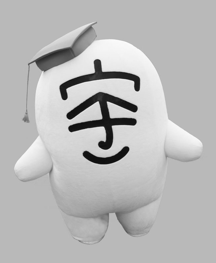

In [15]:
import requests
from PIL import Image
#from IPython.display import display

#画像ファイルを読み込み
url = "https://raw.githubusercontent.com/SotaYoshida/Lecture_DataScience/main/notebooks/pic_for_notebook/u_ta.jpeg"
img = Image.open(requests.get(url, stream=True).raw)
gray_img = img.convert('L')
gray_img_show = gray_img.resize((gray_img.width//3, gray_img.height//3))
gray_img_show

full rank =>  597
rank 29 (~ 5 ％) Fnorm  4941.906716516428  # of m.e.  45849


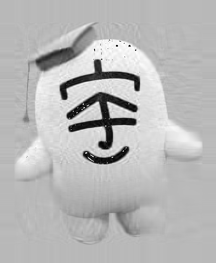

rank 59 (~ 10 ％) Fnorm  2862.789400836713  # of m.e.  93279


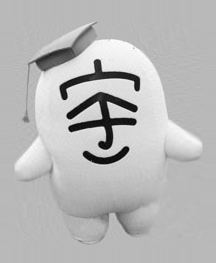

rank 298 (~ 50 ％) Fnorm  290.70038480856283  # of m.e.  471138


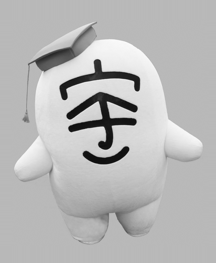

In [16]:
import numpy as np
from scipy import linalg
from numpy.linalg import svd, matrix_rank

# SVDを実行
a = np.asarray(gray_img)
u, s, v = svd(a)
fullrank = matrix_rank(a)
print("full rank => ", fullrank)

# 陽に必要な行列要素の数を計算する関数
def num_of_me(u,s,v,rank):
    m,n = u.shape
    return m * rank + rank + rank*n

#低ランク近似を得る
for factor in [0.05, 0.1, 0.5]:
    rank = int(factor*fullrank)
    ur = u[:, :rank]
    sr = np.matrix(linalg.diagsvd(s[:rank], rank,rank))
    vr = v[:rank, :]
    b = np.asarray(ur*sr*vr)
    img = Image.fromarray(np.uint8(b))
    USVd = np.dot(ur, np.dot(sr,vr))
    print("rank",rank, "(~", int(factor*100), "％) Fnorm ", linalg.norm(a-USVd,"fro"), " # of m.e. ", num_of_me(u,s,v,rank) )
    display(img.resize((img.width//3, img.height//3)))

5%程度の特異値を用いても、ややぼけるが、画像に宇〜太が写っていることは人間の目には明らかである。

## 行列の微分

ベクトル解析の章と重複する部分があるが、行列の微分についても簡単に触れておく。

ベクトルに対する微分を拡張して、行列に対する微分を考えることができる。
まず、ベクトル $\mathbf{a} $に対するスカラー$x$による微分を以下のように定義する:

$$
\begin{align*}
& \left( \frac{\partial \mathbf{a}}{\partial x} \right)_i = \frac{\partial a_i}{\partial x}  \\
& \Leftrightarrow
\frac{\partial \mathbf{a}}{\partial x} = \begin{bmatrix}
\frac{\partial a_1}{\partial x} & 
\frac{\partial a_2}{\partial x} & \cdots & \frac{\partial a_n}{\partial x}
\end{bmatrix}^T
\end{align*}
$$

同様に、行列 $\mathbf{A}$ に対するスカラー $x$ による微分は次のように定義される:

$$
\begin{align*}
\left( \frac{\partial \mathbf{A}}{\partial x} \right)_{ij} &= \frac{\partial A_{ij}}{\partial x}
\end{align*}
$$

また、スカラー値$x$に対するベクトル$\mathbf{a}$の微分は次のように定義される:

$$
\begin{align*}
\left( \frac{\partial x}{\partial \mathbf{a}} \right)_i &= \frac{\partial x}{\partial a_i} \\
\Leftrightarrow
\frac{\partial x}{\partial \mathbf{a}} &= \begin{bmatrix}
\frac{\partial x}{\partial a_1} & \frac{\partial x}{\partial a_2} & \cdots & \frac{\partial x}{\partial a_n}
\end{bmatrix}^T
\end{align*}
$$

これから、スカラー値$\mathbf{x}^T \mathbf{a}$の$\mathbf{x}$に関する微分は以下のように計算できる:

$$
\begin{align*}
\frac{\partial}{\partial \mathbf{x}} (\mathbf{x}^T \mathbf{a}) 
&= \frac{\partial}{\partial \mathbf{x}} (\mathbf{a}^T \mathbf{x})  
= \frac{\partial}{\partial \mathbf{x}} \left( \sum_{i=1}^n x_i a_i \right) \\
&= \begin{bmatrix}
\frac{\partial}{\partial x_1} \left( \sum_{i=1}^n x_i a_i \right) &
\frac{\partial}{\partial x_2} \left( \sum_{i=1}^n x_i a_i   \right) &
\cdots & \frac{\partial}{\partial x_n} \left( \sum_{i=1}^n x_i a_i   \right)
\end{bmatrix}^T \\
&= \begin{bmatrix}
a_1 & a_2 & \cdots & a_n
\end{bmatrix}^T \\
&= \mathbf{a}
\end{align*}
$$

さらにこれを拡張すると、行列$\mathbf{A}, \mathbf{B}$に対して次のように計算できる:

$$
\begin{align*}
\frac{\partial}{\partial \mathbf{x}} ( \mathbf{A} \mathbf{B} )
& = \frac{\partial \mathbf{A}}{\partial \mathbf{x}} \mathbf{B} + \mathbf{A} \frac{\partial \mathbf{B}}{\partial \mathbf{x}}
\end{align*}
$$


`````{admonition} 重要な式
:class: tip

多次元正規分布の対数尤度の微分などで必要な重要な式を導出しておこう。

$$
\begin{align*}
\frac{\partial}{\partial x} \mathbf{A}^{-1} &= -\mathbf{A}^{-1} \frac{\partial \mathbf{A}}{\partial x} \mathbf{A}^{-1} \\
\frac{\partial}{\partial x} \log |\mathbf{A}| &= \mathrm{tr} \left( \mathbf{A}^{-1} \frac{\partial \mathbf{A}}{\partial x} \right)
\end{align*}
$$

1つめの式は、$\mathbf{A} \mathbf{A}^{-1} = \mathbf{I}$を$x$で微分して導出できる。
2つめの式は、余因子行列を用いて導出する方法や、実対称行列の固有値分解を用いて導出する方法などがある。
前者について、以下に発展的な注として示しておく。
`````

$\clubsuit$ 余因子行列を用いた行列式の対数の微分の導出

$a_{ij}$に対する行列$\mathbf{A}$の余因子を$\tilde{a}_{ij}$と書く。
なお、余因子行列は

$$
\begin{align*}
\tilde{a}_{ij} = (-1)^{i+j} \left| M_{ij}\right|
\end{align*}
$$

で、$M_{ij}$は行列$\mathbf{A}$の$i$行$j$列を除いた小行列である。
行列式の定義(線形代数の教科書などを参照)の一つとして、

$$
\begin{align*}
|\mathbf{A}| = \sum_{k} a_{ik} \tilde{a}_{ik}
\end{align*}
$$
がある(余因子展開)。
これを$a_{ij}$で微分すると、

$$
\begin{align*}
\frac{\partial}{\partial a_{ij}} |\mathbf{A}|
= \frac{\partial}{\partial a_{ij}} \left( \sum_k a_{ik} \tilde{a}_{ik} \right) = \tilde{a}_{ij}
\end{align*}
$$
となる。
$|\mathbf{A}|$の$x$に対する偏微分が、各要素$a_{ij}$に対する偏微分の総和で表されることから、

$$
\begin{align*}
\frac{\partial}{\partial x} |\mathbf{A}|
&= \sum_{i,j} \frac{\partial |\mathbf{A}|}{\partial a_{ij}} \frac{\partial a_{ij}}{\partial x} \\
&= \sum_{i,j} \tilde{a}_{ij} \frac{\partial a_{ij}}{\partial x} \\
&= |\mathbf{A}| \sum_{i,j} (\mathbf{A}^{-1})_{ji} \frac{\partial a_{ij}}{\partial x} \\
&= |\mathbf{A}| \mathrm{tr} \left( \mathbf{A}^{-1} \frac{\partial \mathbf{A}}{\partial x} \right)
\end{align*}
$$

となる。ここでは、以下の余因子行列と逆行列の関係を用いた:

$$
\begin{align*}
\mathbf{A}^{-1} & = \frac{1}{|\mathbf{A}|} \tilde{\mathbf{A}}\\
(\tilde{\mathbf{A}}^T)_{ij} & = \tilde{a}_{ij}
\end{align*}
$$

したがって、対数の微分を考えると目的の式が得られる。


## 行列の指数関数

線形常微分方程式の解法や、量子力学における時間発展など、行列の指数関数が重要な役割を果たす場合がある。

行列$A$の指数関数は、テイラー展開を用いて以下のように定義される:

$$
\exp(A) = \sum^\infty_{n=0} \frac{A^n}{n!} = I + A + \frac{A^2}{2!} + \frac{A^3}{3!} + \cdots
$$


行列の指数関数は以下のような性質を持つ:

$$
\begin{align*}
\exp(-A) * \exp(A) & = I \\
\exp(A)^\dagger & = \exp(A^\dagger) \\
B \exp(A) B^{-1} & = \exp(B A B^{-1}) \\
\exp(A+B) & = \exp(A) \exp(B) \quad (AB=BA \text{ のとき}) \\
\exp(-A)B \exp(A) & = B + [B, A] + \frac{1}{2!}[[B, A], A] + \frac{1}{3!}[[[B, A], A], A] + \cdots \\
\exp(A) B \exp(-A) & = B + [A, B] + \frac{1}{2!}[A, [A, B]] + \frac{1}{3!}[A, [A, [A, B]]] + \cdots
\end{align*}
$$

なお $[A, B] = AB - BA$ は $A$ と $B$ の**交換子**である。最後の2つの式は、**ベーカー・キャンベル・ハウスドルフ(Baker-Campbell-Hausdorff)の公式**と呼ばれる。
スカラー値の場合と異なり、一般に行列の積は可換でないため、$\exp(A+B) = \exp(A)\exp(B)$は一般には成り立たないことに注意が必要である。

また、行列$U$がユニタリ行列(エルミート共役が逆行列に等しい)であるとき、$U$は反エルミート行列$X$の指数関数として表現できる。

## PyTorchにおける行列・ベクトルの表現

PyTorchでは`Torch.Tensor`が行列やベクトルを表現する。
`Torch.Tensor`は、行列・ベクトルに係る演算を効率化するために最適化されている。

数値の配列を表現するのに、メモリ上でのデータの連続性を保つように設計されている。
また、特定の行・列を抽出したり、行列の形状を指定して操作する際に、無駄なメモリコピーを避ける工夫もされている。

PyTorchのテンソルはGPU上での計算もサポートしており、大規模な行列演算や機械学習モデルの学習において高速な計算が可能である。
また、ニューラルネットワークの学習で重要となる誤差逆伝播法に適した自動微分機能を備えている。

## **学習の振り返りのためのチェックリスト**

▢ 　行列・ベクトルの基本的な演算を説明できる  
▢ 　行列式とトレースの意味や性質を説明できる  
▢ 　逆行列の定義と可逆行列(正則行列)の条件を説明できる  
▢ 　固有値・固有ベクトルの定義と特性を説明できる  
▢ 　行列分解の代表的な手法の概要を説明できる  
